   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

/tmp/ipykernel_955/4289847403.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_955/4289847403.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

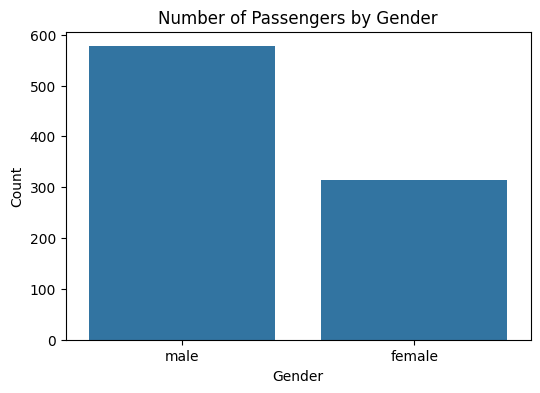

/tmp/ipykernel_955/4289847403.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='Set2')


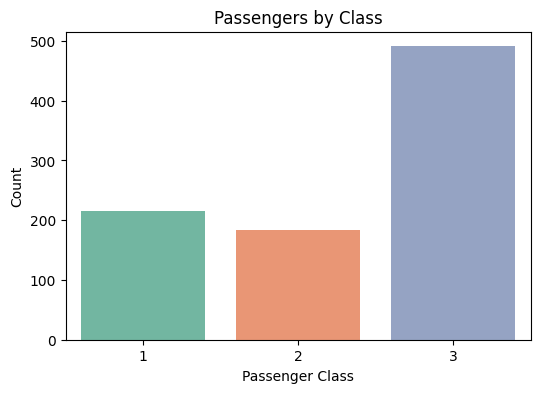

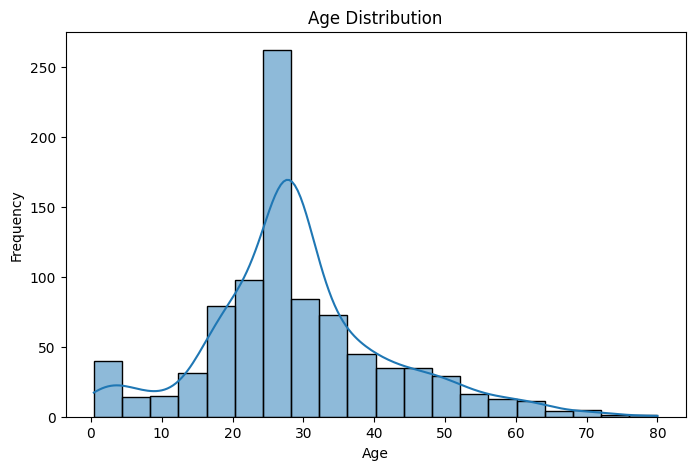

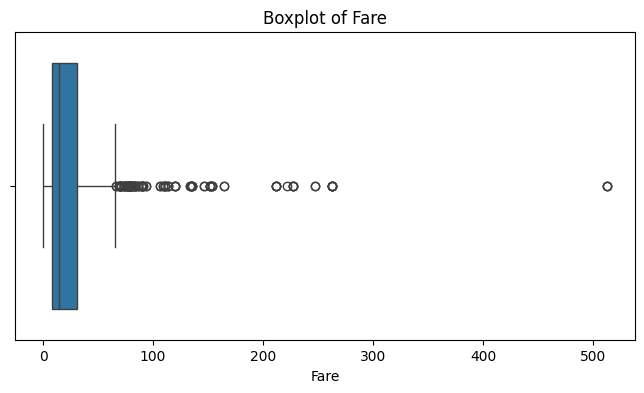

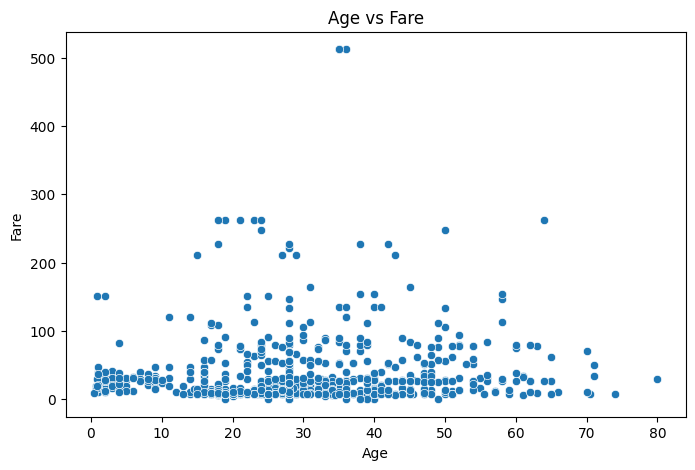

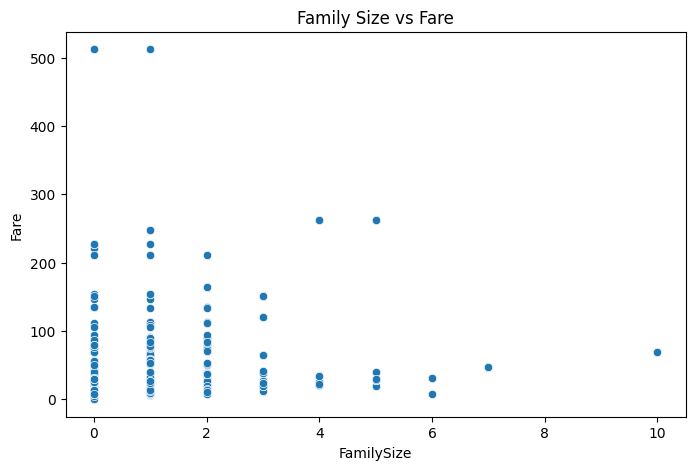

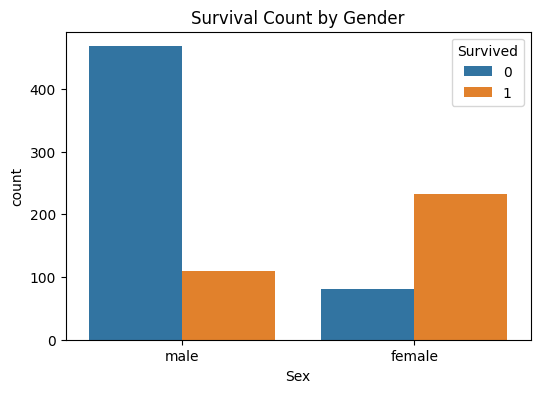

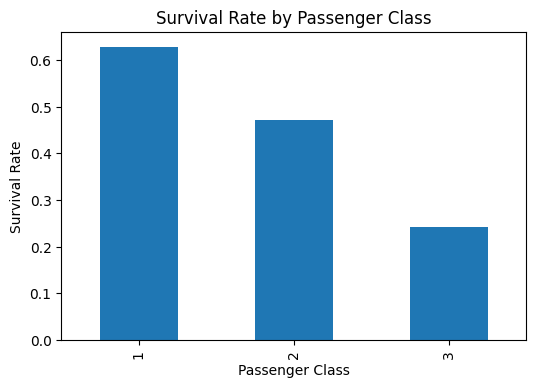

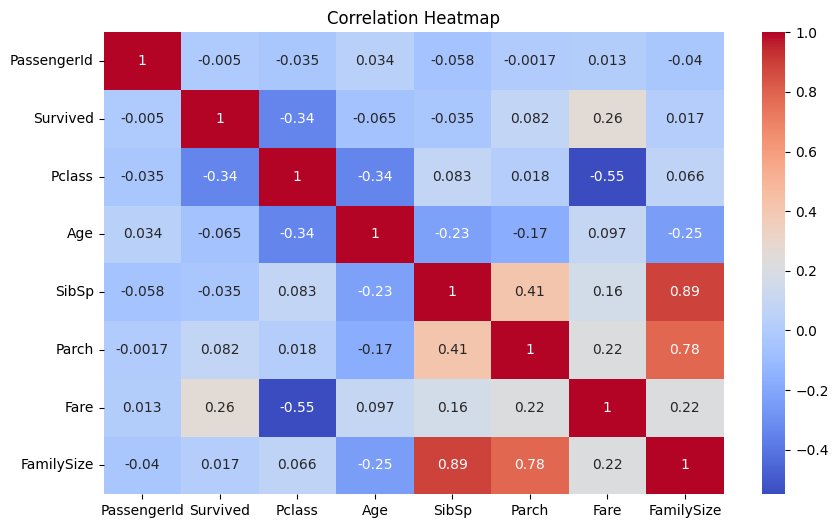

Average Fare by Class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Passenger Class 1 paid the highest average fare.

1. Male passengers outnumbered female passengers.
2. Most passengers belonged to Class 3.
3. Most passengers were between 20-40 years old.
4. Female passengers had a higher survival rate.
5. First-class passengers had the highest survival rate.
6. Higher fares were associated with better survival chances.
7. Fare contained several outliers.
8. Passenger class strongly influenced survival probability.



In [1]:
# =====================================
# Titanic Passenger Analysis - EDA
# =====================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("Titanic.csv")

# =====================================
# Basic Exploration
# =====================================

print(df.head())
print(df.info())
print(df.describe())

# =====================================
# Handling Missing Values
# =====================================

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# =====================================
# Q1: Countplot - Gender
# =====================================

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)
plt.title("Number of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Interpretation:
# Male passengers are greater in number than female passengers.

# =====================================
# Q2: Passenger Class Distribution
# =====================================

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df, palette='Set2')
plt.title("Passengers by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

# Interpretation:
# Most passengers belonged to Class 3.

# =====================================
# Q3: Age Distribution
# =====================================

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Interpretation:
# Most passengers were between 20 and 40 years old.

# =====================================
# Q4: Fare Boxplot
# =====================================

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

# Interpretation:
# Fare contains several outliers.

# =====================================
# Q5(a): Age vs Fare
# =====================================

plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title("Age vs Fare")
plt.show()

# Interpretation:
# No strong relationship exists between age and fare.

# =====================================
# Q5(b): Family Size vs Fare
# =====================================

df['FamilySize'] = df['SibSp'] + df['Parch']

plt.figure(figsize=(8,5))
sns.scatterplot(x='FamilySize', y='Fare', data=df)
plt.title("Family Size vs Fare")
plt.show()

# Interpretation:
# Larger families tend to pay higher fares.

# =====================================
# Q6: Survival by Gender
# =====================================

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival Count by Gender")
plt.show()

# Interpretation:
# Female passengers had higher survival counts.

# =====================================
# Q7: Survival by Class
# =====================================

survival_rate = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(6,4))
survival_rate.plot(kind='bar')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

# Interpretation:
# First-class passengers had the highest survival rate.

# =====================================
# Q8: Correlation Heatmap
# =====================================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Interpretation:
# Fare positively correlates with survival.

# =====================================
# Q9: Highest Average Fare
# =====================================

avg_fare = df.groupby('Pclass')['Fare'].mean()

print("Average Fare by Class:")
print(avg_fare)

highest_class = avg_fare.idxmax()

print(f"\nPassenger Class {highest_class} paid the highest average fare.")

# =====================================
# Q10: Final Insights
# =====================================

print("""
1. Male passengers outnumbered female passengers.
2. Most passengers belonged to Class 3.
3. Most passengers were between 20-40 years old.
4. Female passengers had a higher survival rate.
5. First-class passengers had the highest survival rate.
6. Higher fares were associated with better survival chances.
7. Fare contained several outliers.
8. Passenger class strongly influenced survival probability.
""")